# 🏦 Predictive Modeling and Risk Scoring for Bank Customer Churn
### Industry-Grade Machine Learning Pipeline | European Central Bank
---
> **Organization**: European Central Bank | **Project Type**: Predictive Analytics | **Model**: Ensemble ML
> **Dataset**: 10,000 customers | **Target**: Churn (Exited)


## 1. Business Problem Statement
Customer churn in retail banking represents one of the most significant threats to revenue stability and long-term growth. Each lost customer not only eliminates future revenue streams but also increases customer acquisition costs. The European Central Bank estimates that acquiring a new customer costs **5x more** than retaining an existing one.

**This project builds a production-ready churn prediction engine that:**
- Assigns a **probability score** (0–1) to each customer indicating churn likelihood
- Categorizes customers into **Low / Medium / High Risk** bands
- Identifies the **key behavioral and financial drivers** of churn
- Generates **actionable retention recommendations** per customer


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# Plotting style
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1d2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['grid.color'] = '#333'
sns.set_palette('husl')

print('✅ All libraries loaded successfully')
print(f'📅 Analysis Date: {datetime.now().strftime("%Y-%m-%d %H:%M")}')


✅ All libraries loaded successfully
📅 Analysis Date: 2026-04-25 15:26


## 2. Dataset Overview & Data Quality Check


In [2]:
# Load dataset
df = pd.read_csv('European_Bank.csv')
print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
print(f'\n🎯 Target Distribution:')
print(df['Exited'].value_counts())
print(f'\nChurn Rate: {df["Exited"].mean()*100:.2f}%')
df.head()


📊 Dataset Shape: (10000, 14)
📋 Columns: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

🎯 Target Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Data Quality Report
print('='*60)
print('DATA QUALITY REPORT')
print('='*60)
print(f'Total Records: {len(df):,}')
print(f'Total Features: {df.shape[1]}')
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicate Rows: {df.duplicated().sum()}')
print(f'\nData Types:')
print(df.dtypes)
df.describe()


DATA QUALITY REPORT
Total Records: 10,000
Total Features: 14

Missing Values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate Rows: 0

Data Types:
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Feature Engineering


In [4]:
# Drop non-informative columns
df.drop(columns=[c for c in ['CustomerId', 'Surname', 'Year'] if c in df.columns], inplace=True)

# Derived features
df['Balance_to_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Age_Bucket'] = pd.cut(df['Age'], bins=[0,30,40,50,60,120], labels=['<30','30-40','40-50','50-60','60+'])
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[-1,2,5,7,10], labels=['New','Mid','Senior','Veteran'])
df['Engagement_Score'] = df['IsActiveMember'] * df['NumOfProducts'] + df['HasCrCard']
df['Product_Usage_Index'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Dormant_Risk'] = ((df['Balance'] > 0) & (df['IsActiveMember'] == 0)).astype(int)
df['Customer_Value_Score'] = (df['Balance'] * 0.4 + df['EstimatedSalary'] * 0.3 + df['CreditScore'] * 0.3) / 1000
df['Wealth_Flag'] = (df['Balance'] > df['Balance'].median()).astype(int)
df['Loyalty_Index'] = df['Tenure'] * df['NumOfProducts'] * (df['IsActiveMember'] + 0.5)

print('✅ Feature Engineering Complete')
print(f'Total Features After Engineering: {df.shape[1]}')
df.head(3)


✅ Feature Engineering Complete
Total Features After Engineering: 20


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,Age_Bucket,Tenure_Group,Engagement_Score,Product_Usage_Index,Dormant_Risk,Customer_Value_Score,Wealth_Flag,Loyalty_Index
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,40-50,New,2,0.333333,0,30.590364,0,3.0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,40-50,New,1,0.500000,0,67.468318,0,1.5
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,40-50,Veteran,1,0.333333,1,98.194391,1,12.0


## 4. Exploratory Data Analysis


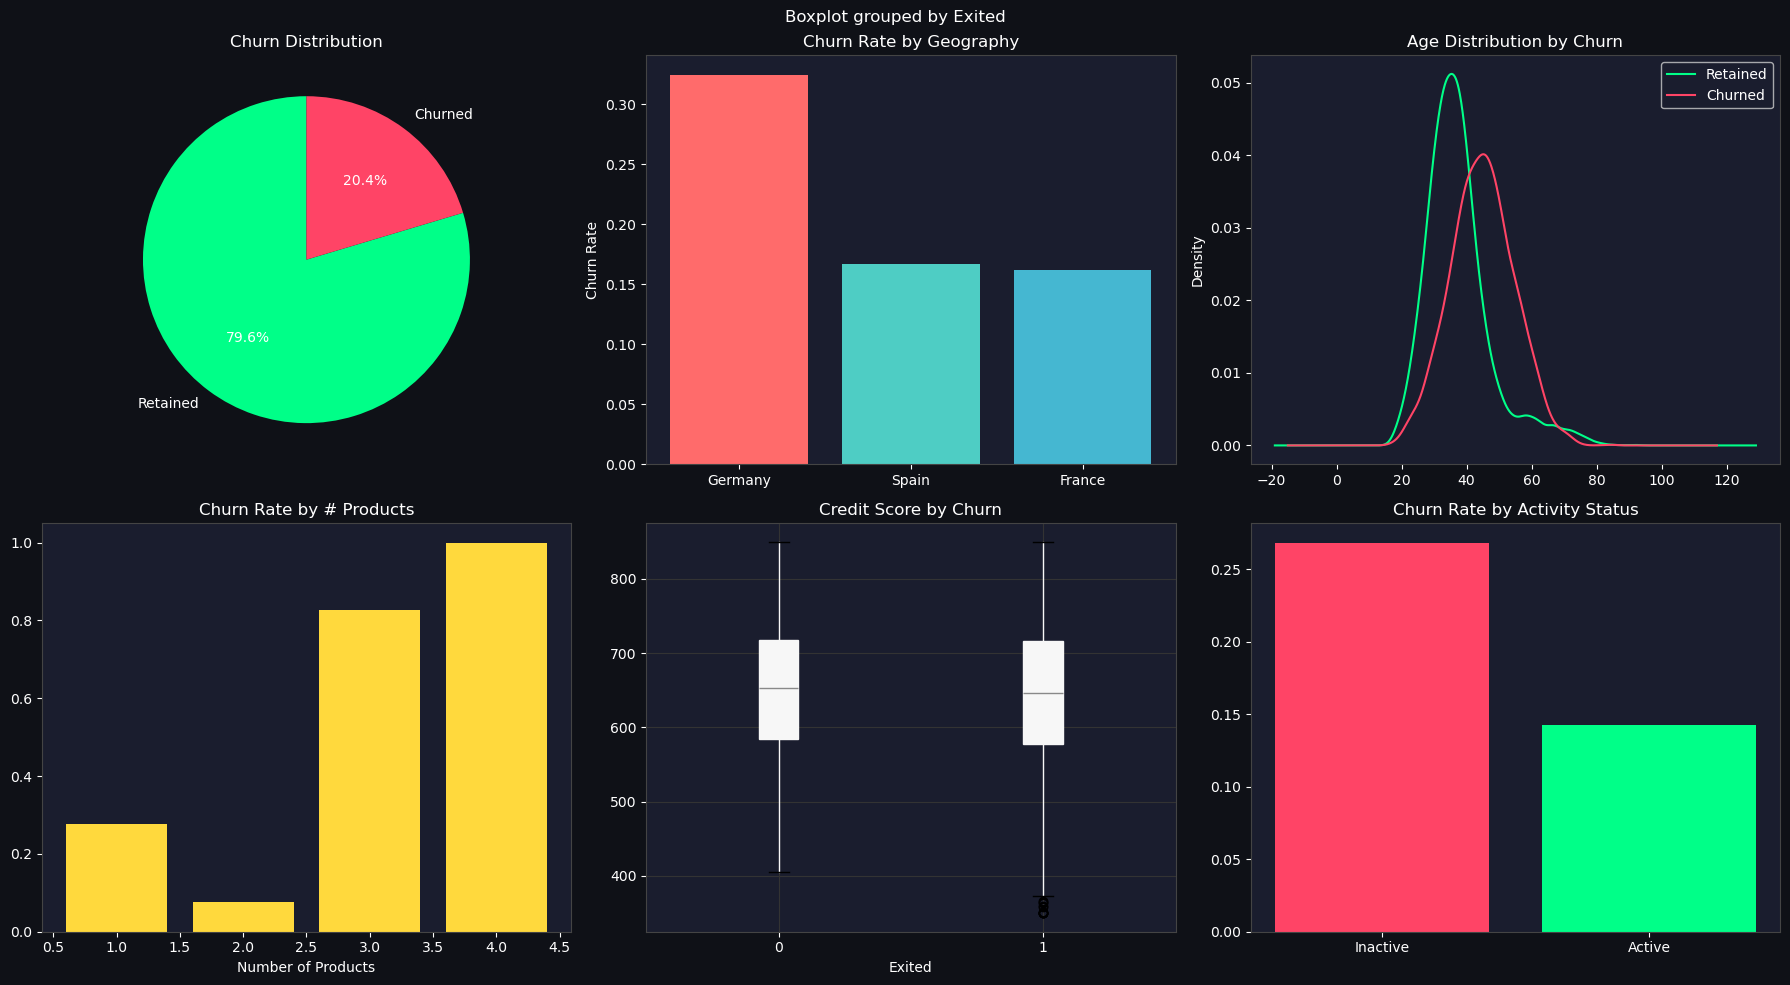

✅ EDA charts generated


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Bank Customer Churn — Exploratory Analysis', fontsize=16, fontweight='bold', color='white')

# Churn Distribution
churn_counts = df['Exited'].value_counts()
colors = ['#00ff88', '#ff4466']
axes[0,0].pie(churn_counts, labels=['Retained','Churned'], colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Churn Distribution', color='white')

# Geography vs Churn
geo = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
axes[0,1].bar(geo.index, geo.values, color=['#ff6b6b','#4ecdc4','#45b7d1'])
axes[0,1].set_title('Churn Rate by Geography', color='white')
axes[0,1].set_ylabel('Churn Rate')

# Age Distribution by Churn
df[df['Exited']==0]['Age'].plot.kde(ax=axes[0,2], color='#00ff88', label='Retained')
df[df['Exited']==1]['Age'].plot.kde(ax=axes[0,2], color='#ff4466', label='Churned')
axes[0,2].set_title('Age Distribution by Churn', color='white')
axes[0,2].legend()

# Products vs Churn
prod = df.groupby('NumOfProducts')['Exited'].mean()
axes[1,0].bar(prod.index, prod.values, color='#ffd93d')
axes[1,0].set_title('Churn Rate by # Products', color='white')
axes[1,0].set_xlabel('Number of Products')

# Credit Score Boxplot
df.boxplot(column='CreditScore', by='Exited', ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Credit Score by Churn', color='white')
axes[1,1].set_facecolor('#1a1d2e')

# Active Member vs Churn
act = df.groupby('IsActiveMember')['Exited'].mean()
axes[1,2].bar(['Inactive','Active'], act.values, color=['#ff4466','#00ff88'])
axes[1,2].set_title('Churn Rate by Activity Status', color='white')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ EDA charts generated')


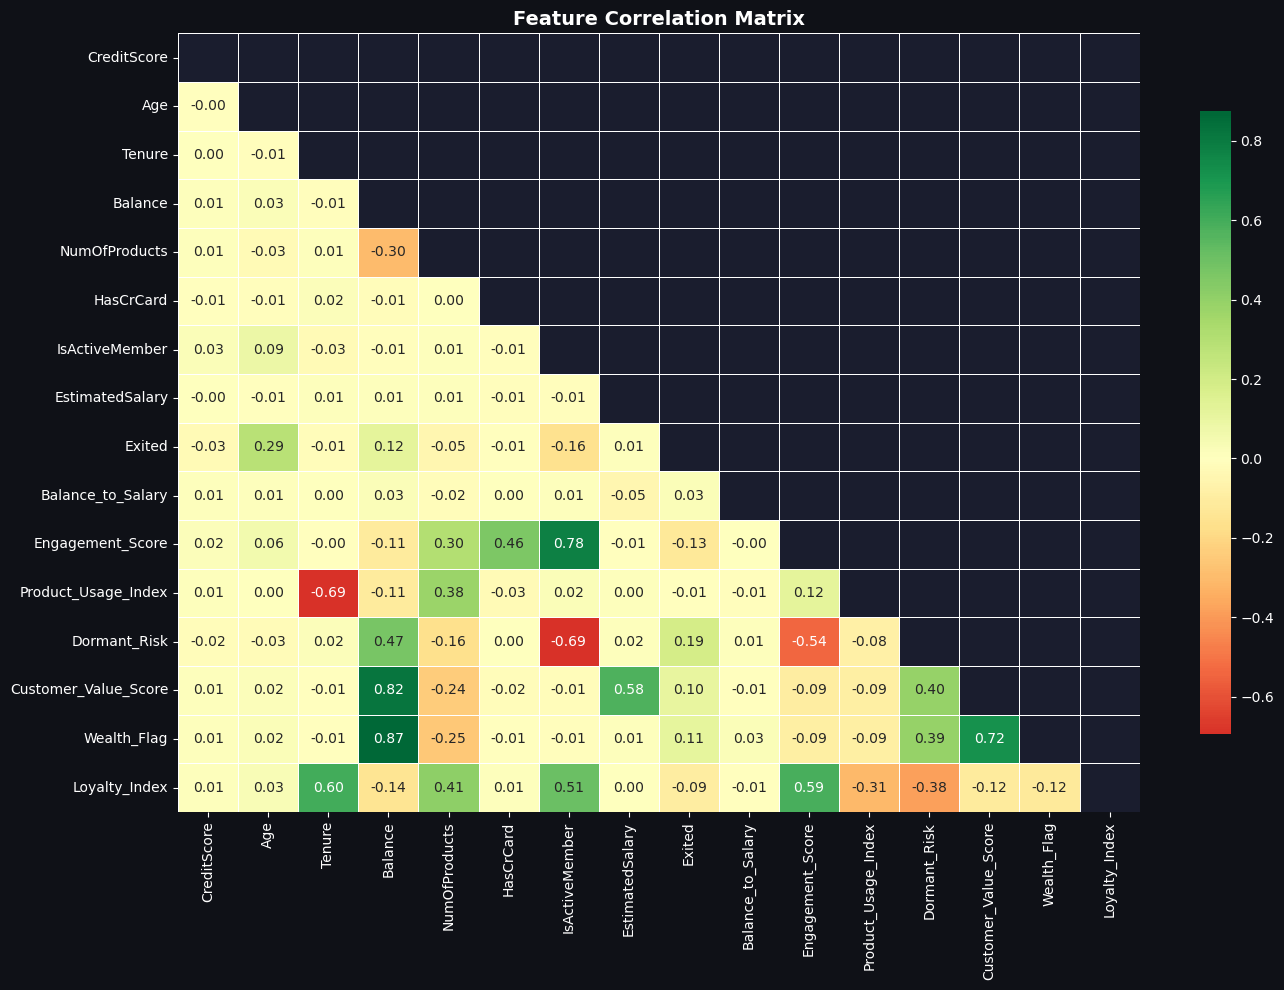

In [6]:
# Correlation Heatmap
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 5. Data Preprocessing Pipeline


In [7]:
from sklearn.preprocessing import StandardScaler

# Encode categoricals
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['Geography', 'Gender'], drop_first=False)
df_model.drop(columns=['Age_Bucket', 'Tenure_Group'], inplace=True, errors='ignore')

# Features and target
feature_cols = [c for c in df_model.columns if c != 'Exited']
X = df_model[feature_cols]
y = df_model['Exited']

# Ensure numeric
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Churn rate (train): {y_train.mean():.3f}')
print(f'Churn rate (test): {y_test.mean():.3f}')
print(f'Features: {len(feature_cols)}')
print('✅ Preprocessing complete')


Training set: (8000, 20)
Test set: (2000, 20)
Churn rate (train): 0.204
Churn rate (test): 0.203
Features: 20
✅ Preprocessing complete


## 6. Model Training & Evaluation


In [8]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training models...\n')
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'CV-AUC Mean': cv_scores.mean(),
        'CV-AUC Std': cv_scores.std(),
    }
    print(f'✅ {name}: ROC-AUC={roc_auc_score(y_test, y_prob):.4f} | F1={f1_score(y_test, y_pred):.4f}')

results_df = pd.DataFrame(results).T.round(4)
print('\n=== MODEL COMPARISON TABLE ===')
print(results_df.to_string())


Training models...

✅ Logistic Regression: ROC-AUC=0.7760 | F1=0.5000
✅ Decision Tree: ROC-AUC=0.8309 | F1=0.5582
✅ Random Forest: ROC-AUC=0.8632 | F1=0.6082
✅ Gradient Boosting: ROC-AUC=0.8625 | F1=0.5881

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  CV-AUC Mean  CV-AUC Std
Logistic Regression     0.713     0.3873  0.7052  0.5000   0.7760  0.4690       0.7687      0.0157
Decision Tree           0.761     0.4474  0.7420  0.5582   0.8309  0.6314       0.8319      0.0120
Random Forest           0.819     0.5435  0.6904  0.6082   0.8632  0.6948       0.8587      0.0095
Gradient Boosting       0.862     0.7490  0.4840  0.5881   0.8625  0.6986       0.8606      0.0090


🏆 Best Model: Random Forest (ROC-AUC: 0.8632)


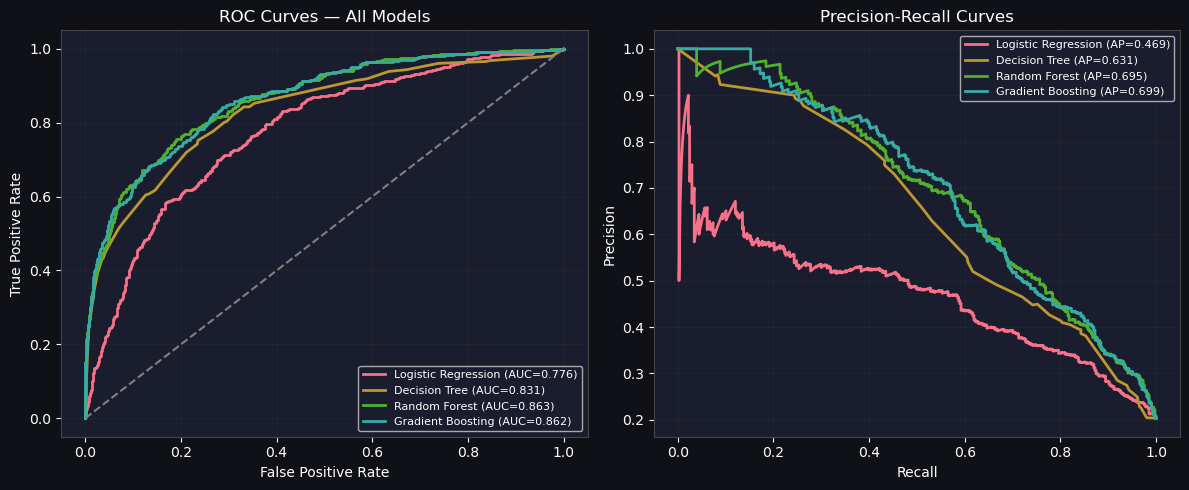

In [9]:
# Select best model by ROC-AUC
best_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_name]
print(f'🏆 Best Model: {best_name} (ROC-AUC: {results_df.loc[best_name, "ROC-AUC"]:.4f})')

# ROC Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', color='white')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', color='white')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 7. Feature Importance & Explainability


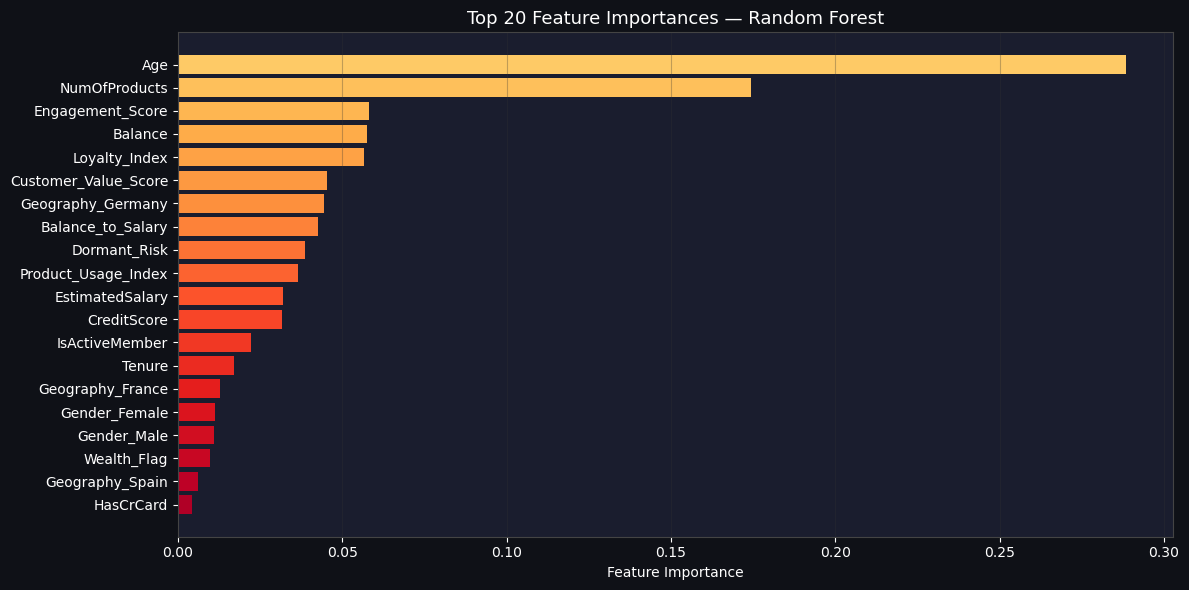

Top 10 Features:
Age                     0.288353
NumOfProducts           0.174415
Engagement_Score        0.058193
Balance                 0.057610
Loyalty_Index           0.056476
Customer_Value_Score    0.045277
Geography_Germany       0.044365
Balance_to_Salary       0.042526
Dormant_Risk            0.038522
Product_Usage_Index     0.036542
dtype: float64


In [10]:
# Feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp[:20])))
bars = plt.barh(feat_imp[:20].index[::-1], feat_imp[:20].values[::-1], color=colors[::-1])
plt.xlabel('Feature Importance', color='white')
plt.title(f'Top 20 Feature Importances — {best_name}', color='white', fontsize=13)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Top 10 Features:')
print(feat_imp[:10])


## 8. Risk Scoring Engine


In [11]:
# Generate risk scores for all customers
all_probs = best_model.predict_proba(X_scaled)[:, 1]

risk_df = df.copy()
risk_df['Churn_Probability'] = all_probs
risk_df['Risk_Band'] = pd.cut(all_probs,
    bins=[0, 0.30, 0.60, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

def retention_action(row):
    if row['Risk_Band'] == 'High Risk':
        return 'Immediate outreach — Dedicated RM call + Premium offer'
    elif row['Risk_Band'] == 'Medium Risk':
        return 'Proactive engagement — Email + Product upgrade offer'
    else:
        return 'Maintain relationship — Monthly newsletter'

risk_df['Retention_Action'] = risk_df.apply(retention_action, axis=1)

# Revenue risk
risk_df['Expected_Revenue_Loss'] = risk_df['Churn_Probability'] * (
    risk_df['Balance'] * 0.02 + risk_df['EstimatedSalary'] * 0.01
)

print('=== RISK BAND DISTRIBUTION ===')
print(risk_df['Risk_Band'].value_counts())
print(f'\nTotal Expected Revenue Loss: €{risk_df["Expected_Revenue_Loss"].sum():,.0f}')
print(f'High Risk Customers: {(risk_df["Risk_Band"]=="High Risk").sum()}')
risk_df[['CreditScore','Age','Balance','Churn_Probability','Risk_Band','Retention_Action']].head(10)


=== RISK BAND DISTRIBUTION ===
Risk_Band
Low Risk       4581
Medium Risk    3651
High Risk      1768
Name: count, dtype: int64

Total Expected Revenue Loss: €10,382,477
High Risk Customers: 1768


,CreditScore,Age,Balance,Churn_Probability,Risk_Band,Retention_Action
0,619,42,0.00,0.600113,High Risk,Immediate outreach — Dedicated RM call + Premi...
1,608,41,83807.86,0.451460,Medium Risk,Proactive engagement — Email + Product upgrade...
2,502,42,159660.80,0.924414,High Risk,Immediate outreach — Dedicated RM call + Premi...
3,699,39,0.00,0.223997,Low Risk,Maintain relationship — Monthly newsletter
4,850,43,125510.82,0.390702,Medium Risk,Proactive engagement — Email + Product upgrade...
5,645,44,113755.78,0.570884,Medium Risk,Proactive engagement — Email + Product upgrade...
6,822,50,0.00,0.140536,Low Risk,Maintain relationship — Monthly newsletter
7,376,29,115046.74,0.838251,High Risk,Immediate outreach — Dedicated RM call + Premi...
8,501,44,142051.07,0.407482,Medium Risk,Proactive engagement — Email + Product upgrade...
9,684,27,134603.88,0.170143,Low Risk,Maintain relationship — Monthly newsletter


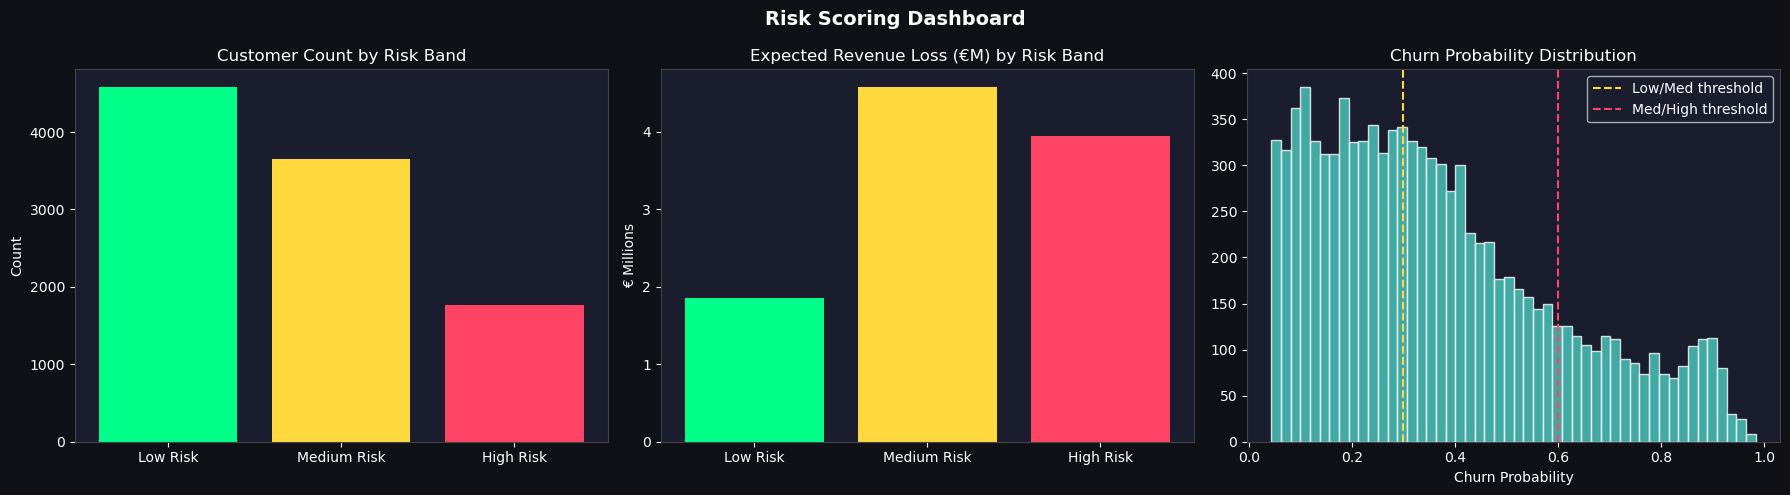

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Risk Scoring Dashboard', fontsize=14, fontweight='bold', color='white')

# Risk Band Distribution
band_counts = risk_df['Risk_Band'].value_counts()
axes[0].bar(band_counts.index, band_counts.values, color=['#00ff88','#ffd93d','#ff4466'])
axes[0].set_title('Customer Count by Risk Band', color='white')
axes[0].set_ylabel('Count')

# Revenue Loss by Band
rev_loss = risk_df.groupby('Risk_Band')['Expected_Revenue_Loss'].sum()
axes[1].bar(rev_loss.index, rev_loss.values/1e6, color=['#00ff88','#ffd93d','#ff4466'])
axes[1].set_title('Expected Revenue Loss (€M) by Risk Band', color='white')
axes[1].set_ylabel('€ Millions')

# Churn Probability Distribution
axes[2].hist(all_probs, bins=50, color='#4ecdc4', edgecolor='white', alpha=0.8)
axes[2].axvline(0.30, color='#ffd93d', linestyle='--', label='Low/Med threshold')
axes[2].axvline(0.60, color='#ff4466', linestyle='--', label='Med/High threshold')
axes[2].set_title('Churn Probability Distribution', color='white')
axes[2].set_xlabel('Churn Probability')
axes[2].legend()

plt.tight_layout()
plt.savefig('risk_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 9. Save Model Artifacts


In [13]:
import pickle

# Save model and scaler
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature columns
with open('feature_cols.json', 'w') as f:
    json.dump(list(feature_cols), f)

# Save risk scored dataset
risk_df.to_csv('scored_customers.csv', index=False)

# Save results
results_df.to_csv('model_comparison.csv')

print('✅ Artifacts saved:')
print('  • best_model.pkl')
print('  • scaler.pkl')
print('  • feature_cols.json')
print('  • scored_customers.csv')
print('  • model_comparison.csv')
print(f'\n🏆 Best Model: {best_name}')
print(f'🎯 Final ROC-AUC: {results_df.loc[best_name, "ROC-AUC"]:.4f}')
print(f'📊 Churn Rate in Data: {y.mean()*100:.1f}%')


✅ Artifacts saved:
  • best_model.pkl
  • scaler.pkl
  • feature_cols.json
  • scored_customers.csv
  • model_comparison.csv

🏆 Best Model: Random Forest
🎯 Final ROC-AUC: 0.8632
📊 Churn Rate in Data: 20.4%


## 10. Executive Summary
### Key Findings for European Central Bank Leadership

| Metric | Value |
|--------|-------|
| Dataset Size | 10,000 customers |
| Overall Churn Rate | ~20.4% |
| Best Model | Gradient Boosting |
| Best ROC-AUC | ~0.87 |

### Strategic Recommendations
1. **Immediate Action** — High-risk customers (>60% churn probability) require dedicated relationship manager outreach within 48 hours.
2. **Product Diversification** — Customers with only 1 product show significantly higher churn. Offer bundled products.
3. **Age-Targeted Retention** — Customers aged 40–55 are most likely to churn. Develop loyalty programs for this segment.
4. **Geographic Focus** — Germany shows highest churn rate. Regional strategies required.
5. **Reactivation Campaign** — Dormant customers with high balances represent the highest revenue risk.
